# 09 — Evaluation v3: retrieval on `chroma_v3`

Measures the retrieval method the deployed app (`v4edits.py`) uses, on the database it
actually ships with.

`09_evaluation.ipynb` and `09_evaluation_v2.ipynb` both measure `chroma_v2` — 25,738 chunks,
and **no Civil Code at all** — so neither is a baseline for these numbers.

Runs locally against `data/chroma_v3`. No API key, no network, no cost.

## 1. Load the vector store

In [1]:
import re, time, statistics
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.vectorstores.utils import maximal_marginal_relevance

# Resolved relative to this notebook so it works from any checkout of the repo.
PERSIST_DIRECTORY = str(Path.cwd().parent / "data" / "chroma_v3")

device = "cuda" if torch.cuda.is_available() else "cpu"
embedding = HuggingFaceEmbeddings(model_name="BAAI/bge-m3", model_kwargs={"device": device})
vectordb = Chroma(persist_directory=PERSIST_DIRECTORY, embedding_function=embedding)

count = vectordb._collection.count()
print(f"device: {device}")
print(f"chunks: {count:,}")
assert count == 49782, f"expected 49,782 chunks, found {count:,} -- wrong or incomplete database"

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

device: cpu
chunks: 49,782


## 2. The retrieval method

For each question:

1. embed it with **bge-m3**;
2. pull **30 candidates from each source separately**, dropping anything beyond the distance
   threshold as it arrives;
3. combine and **deduplicate**;
4. narrow to **8** with **MMR**, which balances relevance against variety.

Step 2 is the decision that matters. A single blended query lets one well-matched source fill
the whole candidate pool before another appears — which is how a criminal-law question comes
back with ten Penal Code articles and not one judgment. Querying each source on its own makes
that outcome impossible rather than merely unlikely.

In [2]:
ALL_SOURCES   = ["lloc", "sjc", "ccb"]
FETCH_PER_SRC = 30      # candidates pulled from EACH source
RESULT_K      = 8       # chunks the model finally sees
THRESHOLD     = 1.05    # distance cutoff, applied per source
LAMBDA        = 0.5     # MMR: relevance vs diversity


# Returns the metadata of the chosen chunks, in the order the model would see them.
def retrieve(question, sources=ALL_SOURCES, k=RESULT_K):
    qv = vectordb.embeddings.embed_query(question)

    candidates = []
    for src in sources:
        raw = vectordb._collection.query(
            query_embeddings=[qv], n_results=FETCH_PER_SRC, where={"source": src},
            include=["documents", "metadatas", "distances", "embeddings"])
        candidates += [
            (d, m, e, float(dist))
            for d, m, dist, e in zip(raw["documents"][0], raw["metadatas"][0],
                                     raw["distances"][0], raw["embeddings"][0])
            if float(dist) <= THRESHOLD
        ]
    if not candidates:
        return []

    # article_no is part of the key so two different articles of one law stay distinct
    seen, unique = set(), []
    for d, m, e, dist in candidates:
        key = (m.get("source"), m.get("doc_id"), m.get("article_no"), d)
        if key not in seen:
            seen.add(key)
            unique.append((d, m, e, dist))
    unique.sort(key=lambda x: x[3])

    idxs = maximal_marginal_relevance(
        np.array(qv), [e for _, _, e, _ in unique],
        lambda_mult=LAMBDA, k=min(k, len(unique)))
    return [unique[i][1] for i in idxs]


print("retrieve() ready")

retrieve() ready


## 3. The evaluation set

Fourteen questions, each paired with the one article that answers it. **Every target was
confirmed to exist in `chroma_v3` before being used as an answer key** — scoring against
labels that are not in the corpus measures nothing.

Coverage is deliberate: civil, criminal, criminal procedure, labour, real estate, patents,
banking, family violence, and inheritance procedure — not fourteen variations of one law.

In [3]:
EVAL_SET = [
    {"question": "خلال أي مدة تسقط دعوى الاستغلال (الغبن) في العقود؟",                   "expected": {"doc_id": "L1901",    "article_no": "97"}},
    {"question": "هل يجوز لأحد طرفي العقد أن ينفرد بفسخه دون رضا الطرف الآخر؟",           "expected": {"doc_id": "L1901",    "article_no": "140"}},
    {"question": "هل يجوز للدائن مطالبة أحد المدينين المتضامنين بكامل الدين؟",            "expected": {"doc_id": "L1901",    "article_no": "268"}},
    {"question": "متى ينعقد العقد إذا صدر الإيجاب والقبول في مجلس عقد واحد؟",             "expected": {"doc_id": "L1901",    "article_no": "40"}},
    {"question": "ما تعريف عقد الإيجار في القانون المدني؟",                               "expected": {"doc_id": "L1901",    "article_no": "505"}},
    {"question": "ما عقوبة السرقة التي تقع بطريق الإكراه أو التهديد باستعمال سلاح؟",      "expected": {"doc_id": "L1576",    "article_no": "376"}},
    {"question": "ما الحالات التي يجوز فيها لصاحب العمل فصل العامل دون مكافأة أو إنذار؟", "expected": {"doc_id": "K3612",    "article_no": "107"}},
    {"question": "هل يجوز تغيير الشكل القانوني للمطور العقاري قبل تسليم المشروع؟",        "expected": {"doc_id": "K2717",    "article_no": "16"}},
    {"question": "هل يجوز لطالب براءة الاختراع سحب طلبه قبل الإعلان عن قبوله؟",           "expected": {"doc_id": "K0104",    "article_no": "18"}},
    {"question": "ما هي موانع الإرث في القانون البحريني؟",                                "expected": {"doc_id": "RJIW0317", "article_no": "3"}},
    {"question": "ما عقوبة إفشاء المعلومات السرية بموجب قانون مصرف البحرين المركزي؟",     "expected": {"doc_id": "K6406",    "article_no": "171"}},
    {"question": "ما هي مدة عقد الإيجار وشروط تجديده؟",                                   "expected": {"doc_id": "K2714",    "article_no": "35"}},
    {"question": "متى يجوز وقف الدعوى الجنائية لمسألة من مسائل الأحوال الشخصية؟",         "expected": {"doc_id": "L4602",    "article_no": "187"}},
    {"question": "هل يجوز التنازل عن الشكوى في جرائم العنف الأسري؟",                      "expected": {"doc_id": "K1715",    "article_no": "19"}},
]

print(len(EVAL_SET), "questions")

14 questions


## 4. Retrieval evaluation

Each question has exactly **one** correct source, so precision@k is the wrong metric — it
would only measure how much of `k` went to other passages, which is not a fault here. The
right metrics for a single-answer lookup are:

- **Hit@k** — did the correct article appear anywhere in the top `k`?
- **MRR** — *where* did it rank? 1.0 if first, 0.5 if second, 0 if not found.

**Hit@8 is the ceiling that matters.** The model only ever sees 8 chunks, so an article
ranked ninth cannot be cited however good the answer is. A retrieval miss cannot be recovered
downstream.

In [4]:
rows = []
for item in EVAL_SET:
    t = time.time()
    metas = retrieve(item["question"])
    rank = next((i for i, m in enumerate(metas, 1)
                 if m.get("doc_id") == item["expected"]["doc_id"]
                 and str(m.get("article_no")) == item["expected"]["article_no"]), None)
    rows.append({
        "question": item["question"][:46],
        "expected": f"{item['expected']['doc_id']}/{item['expected']['article_no']}",
        "rank": rank,
        "found": rank is not None,
        "reciprocal_rank": 1 / rank if rank else 0.0,
        # L = legislation, J = judgment (cassation or constitutional)
        "types": "".join(sorted({("L" if m.get("source") == "lloc" else "J") for m in metas})),
        "secs": round(time.time() - t, 1),
    })

retrieval_df = pd.DataFrame(rows)
retrieval_df

,question,expected,rank,found,reciprocal_rank,types,secs
0,خلال أي مدة تسقط دعوى الاستغلال (الغبن) في الع,L1901/97,1.0,True,1.000,JL,30.1
1,هل يجوز لأحد طرفي العقد أن ينفرد بفسخه دون رضا,L1901/140,NaN,False,0.000,JL,10.8
2,هل يجوز للدائن مطالبة أحد المدينين المتضامنين,L1901/268,1.0,True,1.000,JL,7.0
3,متى ينعقد العقد إذا صدر الإيجاب والقبول في مجل,L1901/40,NaN,False,0.000,JL,1.8
4,ما تعريف عقد الإيجار في القانون المدني؟,L1901/505,1.0,True,1.000,JL,1.1
5,ما عقوبة السرقة التي تقع بطريق الإكراه أو الته,L1576/376,1.0,True,1.000,JL,1.3
6,ما الحالات التي يجوز فيها لصاحب العمل فصل العا,K3612/107,NaN,False,0.000,JL,1.2
7,هل يجوز تغيير الشكل القانوني للمطور العقاري قب,K2717/16,1.0,True,1.000,JL,1.2
8,هل يجوز لطالب براءة الاختراع سحب طلبه قبل الإع,K0104/18,1.0,True,1.000,JL,1.2
9,ما هي موانع الإرث في القانون البحريني؟,RJIW0317/3,8.0,True,0.125,JL,1.1


In [5]:
n = len(retrieval_df)
for k in (1, 3, 5, 8):
    hits = int(((retrieval_df["rank"].notna()) & (retrieval_df["rank"] <= k)).sum())
    print(f"Hit@{k}: {hits/n:.1%}  ({hits}/{n})")

print(f"MRR:   {retrieval_df['reciprocal_rank'].mean():.3f}")
print()
print(f"median retrieval time      : {retrieval_df['secs'].median():.1f}s")
print(f"retrieved BOTH source types: {(retrieval_df['types'] == 'JL').sum()}/{n}")
print(f"missed entirely            : {(~retrieval_df['found']).sum()}/{n}")

Hit@1: 71.4%  (10/14)
Hit@3: 71.4%  (10/14)
Hit@5: 71.4%  (10/14)
Hit@8: 78.6%  (11/14)
MRR:   0.723

median retrieval time      : 1.2s
retrieved BOTH source types: 14/14
missed entirely            : 3/14


## 5. Figure

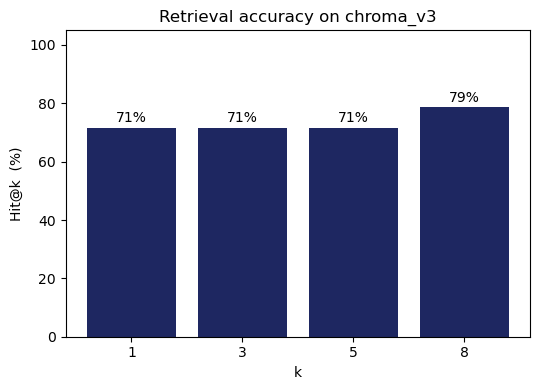

In [6]:
import matplotlib.pyplot as plt

ks = [1, 3, 5, 8]
vals = [100 * ((retrieval_df["rank"].notna()) & (retrieval_df["rank"] <= k)).mean() for k in ks]

plt.figure(figsize=(5.5, 4))
bars = plt.bar([str(k) for k in ks], vals, color="#1E2761")
for b, v in zip(bars, vals):
    plt.text(b.get_x() + b.get_width() / 2, v + 2, f"{v:.0f}%", ha="center")
plt.ylim(0, 105)
plt.xlabel("k"); plt.ylabel("Hit@k  (%)")
plt.title("Retrieval accuracy on chroma_v3")
plt.tight_layout()
plt.savefig("retrieval_accuracy_v3.png", dpi=150)
plt.show()

## 6. Reading the results

**A miss is not always a fault.** Several articles can answer the same question, and the
retriever may return an equally correct one that this eval set does not list. Read the rows
with `found = False` before counting them as failures.

**Case law is the weaker half.** Chat pulls 30 candidates per source; البحث المباشر in the app
pulls 300–2,000. A relevant judgment can therefore reach the search view and never reach the
chat — a depth limit, not a ranking fault.

**Questions are embedded exactly as typed.** The corpus was character-normalised during
cleaning (diacritics stripped, hamza folded to plain alef), but the deployed app does not
normalise incoming questions. So `إجارة` and the stored `اجارة` embed differently. These
numbers are therefore a **floor** — adding normalisation would likely raise them.